### Import Packages

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from keras.models import load_model

wind_model = load_model('wind_transform.keras')

### Load Datasets & Data Preprocessing

In [4]:
cols = ['u','u_e','u_n']
scaled_cols = ['scaled_' + col for col in cols]

# Load datasets
df_stn = pd.read_csv('Sikorsky_data.csv')
df_stn = df_stn.rename(columns={'WSPD':'u'})
df_stn['TmStamp'] = pd.to_datetime(df_stn['TmStamp'], format='mixed')
df_stn.set_index('TmStamp', inplace=True)

df_buoy = pd.read_csv('WLIS_data.csv')
df_buoy = df_buoy.rename(columns={'WSPD':'u'})
df_buoy['TmStamp'] = pd.to_datetime(df_buoy['TmStamp'], format='mixed')
df_buoy.set_index('TmStamp', inplace=True)

# Add east and north components
alpha = -13
df_stn['rad'] = np.pi/180 * ((alpha + 630 - df_stn['WDIR']) % 360)
df_stn['u_e'] = df_stn['u'] * np.cos(df_stn['rad'])
df_stn['u_n'] = df_stn['u'] * np.sin(df_stn['rad'])

df_buoy['rad'] = np.pi/180 * ((alpha + 630 - df_buoy['WDIR']) % 360)
df_buoy['u_e'] = df_buoy['u'] * np.cos(df_buoy['rad'])
df_buoy['u_n'] = df_buoy['u'] * np.sin(df_buoy['rad'])

# Data normalization
scaled_stn_wind, scaled_wind = MinMaxScaler(), MinMaxScaler()
df_stn.loc[:, scaled_cols] = scaled_stn_wind.fit_transform(df_stn[cols])
df_buoy.loc[:, scaled_cols] = scaled_wind.fit_transform(df_buoy[cols])

# Transform station wind into buoy wind
scaled_wind_T = wind_model.predict(df_stn[scaled_cols], verbose=0)
wind_T = scaled_wind.inverse_transform(scaled_wind_T)

# Rename columns
df_buoy = df_buoy[['H'] + cols].rename(columns={col: f'{col}_buoy' for col in cols})
df_stn = df_stn[cols].rename(columns={col: f'{col}_stn' for col in cols})
df_stn_T = pd.DataFrame(wind_T, columns=cols).rename(columns={col: f'{col}_stn_T' for col in cols})
df_stn_T.index = df_stn.index

### Distribution of Features & Target

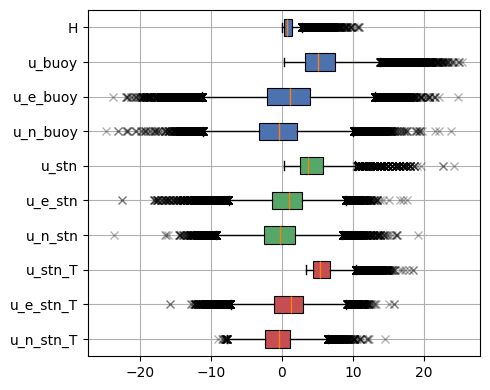

In [5]:
data, labels, colors = [], [], []

for col in df_buoy.columns:
    data.append(df_buoy[col])
    labels.append(col)
    colors.append('#4C72B0')

for col in df_stn.columns:
    data.append(df_stn[col])
    labels.append(col)
    colors.append('#55A868')

for col in df_stn_T.columns:
    data.append(df_stn_T[col])
    labels.append(col)
    colors.append('#C44E52')

data, labels, colors = data[::-1], labels[::-1], colors[::-1]

# Box plot
fig, ax = plt.subplots(figsize=(5, 4))
flierprops = dict(marker='x', markerfacecolor='k', alpha=0.3)
box = ax.boxplot(data, vert=False, patch_artist=True, flierprops=flierprops, boxprops=dict(linewidth=0.8))
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

ax.set_yticklabels(labels)
ax.grid(True)
plt.tight_layout()
plt.show()

### Correlation Analysis

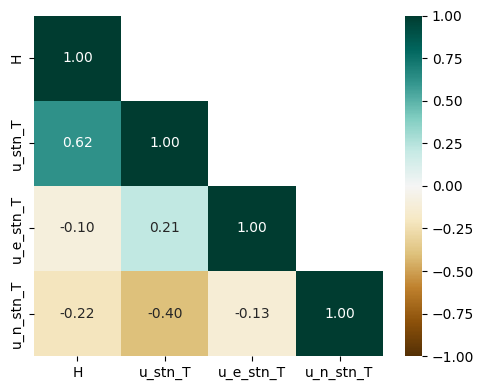

In [6]:
df_corr = pd.concat([df_buoy[['H']], df_stn_T], axis=1).corr()

plt.figure(figsize=(5, 4))
sns.heatmap(df_corr, vmin=-1, vmax=1, center=0, fmt='.2f', annot=True, 
            cmap='BrBG', mask=np.triu(np.ones_like(df_corr), 1))

plt.tight_layout()
plt.show()